In [38]:
import pandas as pd
import numpy as np
from statsmodels.tsa.statespace.sarimax import SARIMAX
from datetime import datetime
import matplotlib.pyplot as plt
from typing import Dict, List


In [39]:
# loading orders and preparing weekly demand data
import os 
ORDERS_PATH = "../output/orders.csv"

orders = pd.read_csv(ORDERS_PATH)
orders["order_date"] = pd.to_datetime(orders["order_date"])

# canonical weekly key
orders["order_week"] = (
    orders["order_date"]
    .dt.to_period("W")
    .apply(lambda p: p.start_time)
)

weekly_demand = (
    orders.groupby(["sku_id", "order_week"])
    .size()
    .reset_index(name="demand")
    .sort_values("order_week")
)


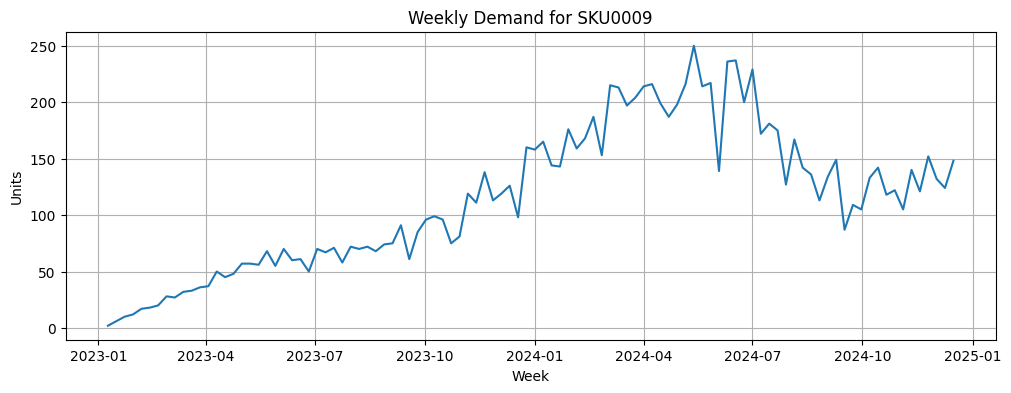

In [40]:
# demand structure diagram 
sample_sku = weekly_demand["sku_id"].iloc[0]

sample_df = weekly_demand[
    weekly_demand["sku_id"] == sample_sku
]

plt.figure(figsize=(12,4))
plt.plot(sample_df["order_week"], sample_df["demand"])
plt.title(f"Weekly Demand for {sample_sku}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.grid(True)
plt.show()


In [41]:
# dymaic sku Routing
def route_sku(ts: pd.Series) -> Dict:
    n_weeks = ts.shape[0]
    non_zero_weeks = (ts > 0).sum()

    if n_weeks >= 52 and non_zero_weeks >= 26:
        return {
            "model": "SARIMAX",
            "seasonal": True,
            "reason": "sufficient_history"
        }
    elif n_weeks >= 12:
        return {
            "model": "NAIVE_MEAN",
            "seasonal": False,
            "reason": "short_history"
        }
    else:
        return {
            "model": "LAST_VALUE",
            "seasonal": False,
            "reason": "very_sparse"
        }


In [42]:
# dyamic forecast horizon
def compute_horizon(n_weeks: int) -> int:
    return max(4, min(26, n_weeks // 2))


In [43]:
# forecast function with recent-history anchoring (Approach A)
def forecast_sarimax(ts: pd.Series, horizon: int, history_weeks: int):
    # Conditional differencing
    if history_weeks >= 52:
        d, D = 0, 0   # preserve trend
    else:
        d, D = 1, 0   # stabilize short history

    model = SARIMAX(
        ts,
        order=(1, d, 1),
        seasonal_order=(1, D, 1, 52),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )

    res = model.fit(disp=False)
    pred = res.get_forecast(horizon)

    mean = pred.predicted_mean
    conf = pred.conf_int(alpha=0.2)  # P10 / P90

 
    # RECENT-HISTORY ANCHOR (Approach A)
  
    RECENT_WEEKS = min(12, history_weeks)
    recent_mean = ts.tail(RECENT_WEEKS).mean()
    recent_std = ts.tail(RECENT_WEEKS).std()

    anchor_weight = 0.3  # 0.2–0.4 is a safe range

    p50 = (1 - anchor_weight) * mean + anchor_weight * recent_mean
    p10 = (1 - anchor_weight) * conf.iloc[:, 0] + anchor_weight * max(
        0, recent_mean - 2 * recent_std
    )
    p90 = (1 - anchor_weight) * conf.iloc[:, 1] + anchor_weight * (
        recent_mean + 2 * recent_std
    )

    return p50, p10, p90


In [44]:
# naive mean 
def forecast_mean(ts: pd.Series, horizon: int):
    mean = ts.mean()
    return (
        pd.Series([mean]*horizon),
        pd.Series([mean*0.8]*horizon),
        pd.Series([mean*1.2]*horizon),
    )


In [45]:
def forecast_last(ts: pd.Series, horizon: int):
    last = ts.iloc[-1]
    return (
        pd.Series([last]*horizon),
        pd.Series([last]*horizon),
        pd.Series([last]*horizon),
    )


In [47]:
results = []

from datetime import datetime, timezone
RUN_DATE = datetime.now(timezone.utc).date()

for sku, df_sku in weekly_demand.groupby("sku_id"):
    ts = df_sku.set_index("order_week")["demand"]
    history_weeks = len(ts)

    routing = route_sku(ts)
    horizon = compute_horizon(history_weeks)

    if routing["model"] == "SARIMAX":
        p50, p10, p90 = forecast_sarimax(ts, horizon, history_weeks)
    elif routing["model"] == "NAIVE_MEAN":
        p50, p10, p90 = forecast_mean(ts, horizon)
    else:
        p50, p10, p90 = forecast_last(ts, horizon)

    future_weeks = pd.period_range(
        ts.index.max(),
        periods=horizon + 1,
        freq="W"
    )[1:].to_timestamp()

    for w, a, b, c in zip(future_weeks, p10, p50, p90):
        results.append({
            "sku_id": sku,
            "week": w,
            "p10": max(0, a),
            "p50": max(0, b),
            "p90": max(0, c),
            "model_type": routing["model"],
            "routing_reason": routing["reason"],
            "history_weeks": history_weeks,
            "run_date": RUN_DATE,
        })


c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.
  self._init_dates(dates, freq)
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
c:\Users\ACER\OneDrive\Documents\GitHub\StockIQ\venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-MON will be used.

In [48]:
forecast_df = pd.DataFrame(results)

forecast_df.to_csv(
    "../artifacts/weekly_forecast_future_all_skus.csv",
    index=False
)


forecast_df.head()


,sku_id,week,p10,p50,p90,model_type,routing_reason,history_weeks,run_date
0,SKU0001,2024-12-23,126.536025,178.290446,230.044866,SARIMAX,sufficient_history,66,2025-12-26
1,SKU0001,2024-12-30,99.032126,150.724045,202.415963,SARIMAX,sufficient_history,66,2025-12-26
2,SKU0001,2025-01-06,75.340209,126.981524,178.622839,SARIMAX,sufficient_history,66,2025-12-26
3,SKU0001,2025-01-13,85.619578,137.219938,188.820297,SARIMAX,sufficient_history,66,2025-12-26
4,SKU0001,2025-01-20,132.509018,184.076240,235.643463,SARIMAX,sufficient_history,66,2025-12-26


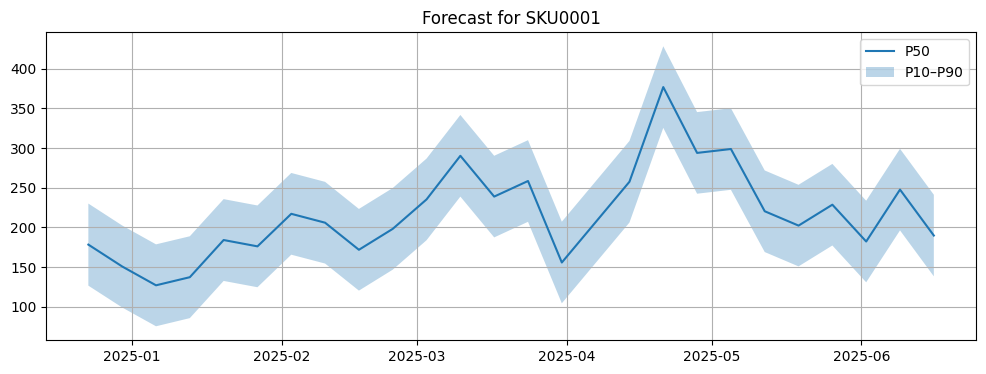

In [49]:
sku = forecast_df["sku_id"].iloc[0]
plot_df = forecast_df[forecast_df["sku_id"] == sku]

plt.figure(figsize=(12,4))
plt.plot(plot_df["week"], plot_df["p50"], label="P50")
plt.fill_between(
    plot_df["week"],
    plot_df["p10"],
    plot_df["p90"],
    alpha=0.3,
    label="P10–P90"
)
plt.title(f"Forecast for {sku}")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
OUTPUT_PATH = "../artifacts/weekly_forecast_future_all_skus.csv"
forecast_df.to_csv(OUTPUT_PATH, index=False)

print(f"Saved forecast to {OUTPUT_PATH}")


Saved forecast to ../artifacts/weekly_forecast_future_all_skus.csv


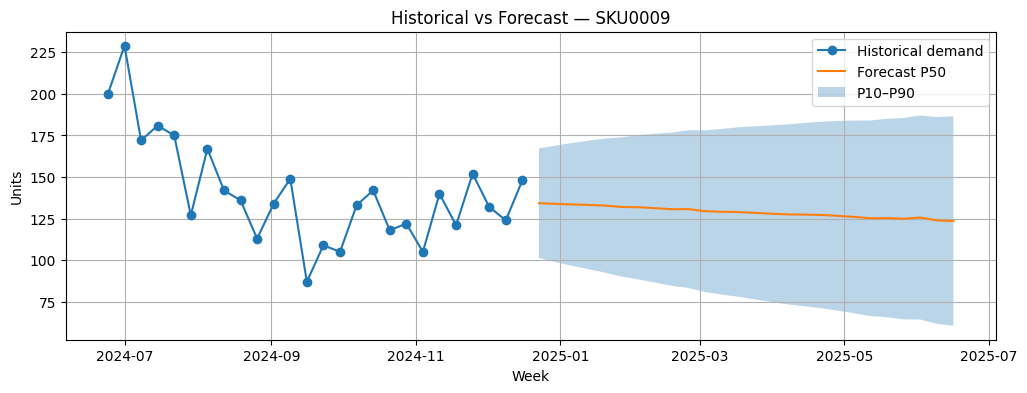

In [51]:
sku = weekly_demand["sku_id"].iloc[0]

hist = weekly_demand[weekly_demand["sku_id"] == sku]
fcst = forecast_df[forecast_df["sku_id"] == sku]

plt.figure(figsize=(12,4))

plt.plot(
    hist["order_week"].tail(26),
    hist["demand"].tail(26),
    label="Historical demand",
    marker="o",
)

plt.plot(
    fcst["week"],
    fcst["p50"],
    label="Forecast P50",
)

plt.fill_between(
    fcst["week"],
    fcst["p10"],
    fcst["p90"],
    alpha=0.3,
    label="P10–P90",
)

plt.title(f"Historical vs Forecast — {sku}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.grid(True)
plt.show()


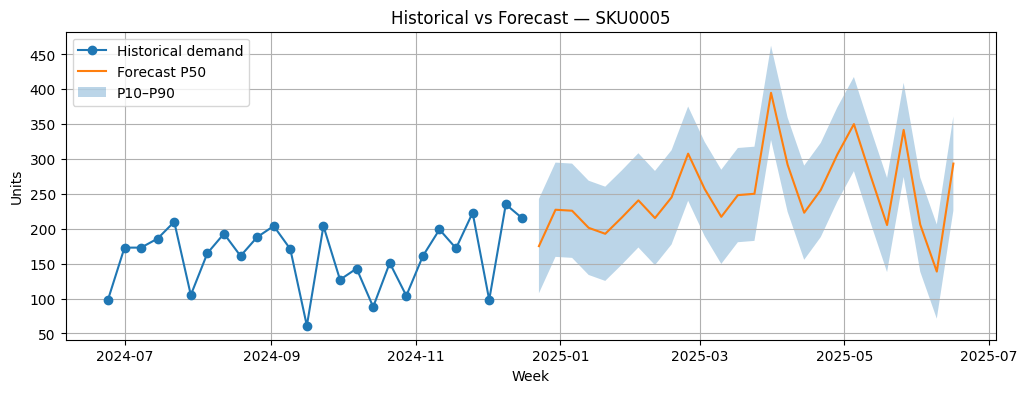

In [53]:
sku = weekly_demand["sku_id"].iloc[0]

hist = weekly_demand[weekly_demand["sku_id"] == "SKU0005"]
fcst = forecast_df[forecast_df["sku_id"] == "SKU0005"]

plt.figure(figsize=(12,4))

plt.plot(
    hist["order_week"].tail(26),
    hist["demand"].tail(26),
    label="Historical demand",
    marker="o",
)

plt.plot(
    fcst["week"],
    fcst["p50"],
    label="Forecast P50",
)

plt.fill_between(
    fcst["week"],
    fcst["p10"],
    fcst["p90"],
    alpha=0.3,
    label="P10–P90",
)

plt.title(f"Historical vs Forecast — {"SKU0005"}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.grid(True)
plt.show()


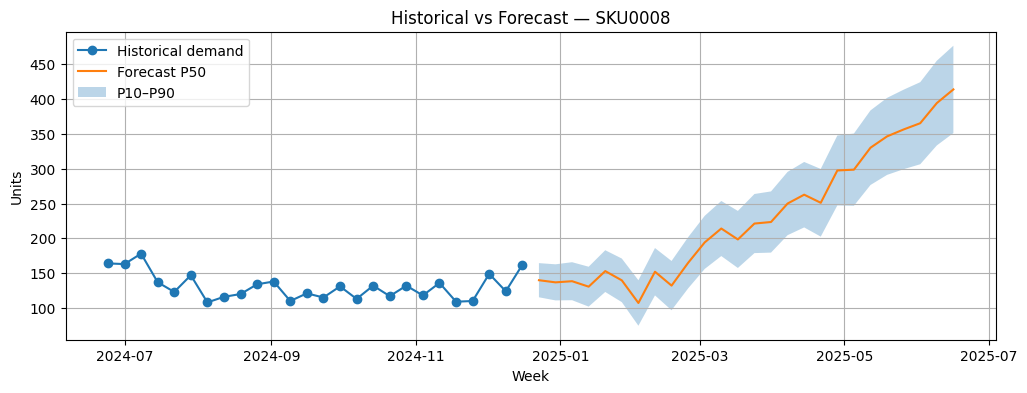

In [54]:
sku = weekly_demand["sku_id"].iloc[0]

hist = weekly_demand[weekly_demand["sku_id"] == "SKU0008"]
fcst = forecast_df[forecast_df["sku_id"] == "SKU0008"]

plt.figure(figsize=(12,4))

plt.plot(
    hist["order_week"].tail(26),
    hist["demand"].tail(26),
    label="Historical demand",
    marker="o",
)

plt.plot(
    fcst["week"],
    fcst["p50"],
    label="Forecast P50",
)

plt.fill_between(
    fcst["week"],
    fcst["p10"],
    fcst["p90"],
    alpha=0.3,
    label="P10–P90",
)

plt.title(f"Historical vs Forecast — {"SKU0008"}")
plt.xlabel("Week")
plt.ylabel("Units")
plt.legend()
plt.grid(True)
plt.show()
